In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import sys

!pip install micrograd

np.random.seed(1337)
random.seed(1337)

from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP

In [7]:
n_layers = 12
iterations = 20
layer_sizes = [9,10]

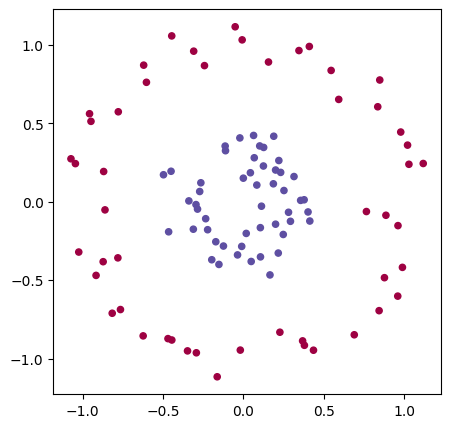

In [17]:
from sklearn.datasets import make_moons, make_blobs, make_circles

X, y = make_circles(n_samples=100, noise=0.1,factor=0.3)
y = y * 2 - 1  # make y be -1 or 1

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap=plt.cm.Spectral)



In [13]:
def loss(model, batch_size=None):

    # inline DataLoader :)
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]

    # forward the model to get scores
    scores = list(map(model, inputs))

    # svm "max-margin" loss
    losses = [(1 + -yi * scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p * p for p in model.parameters()))
    total_loss = data_loss + reg_loss

    # also get accuracy
    accuracy = [
        (yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)
    ]
    return total_loss, sum(accuracy) / len(accuracy)


def train(model, iters=20):
    for k in range(iters):

        # forward
        total_loss, acc = loss(model)

        # backward
        model.zero_grad()
        total_loss.backward()

        # update (sgd)
        learning_rate = 1.0 - 0.9 * k / 100
        for p in model.parameters():
            p.data -= learning_rate * p.grad

        if k % 1 == 0:
            print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

    return model

def plot_decision_boundary(model):
    h = 0.25
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)
    )
    Xmesh = np.c_[xx.ravel(), yy.ravel()]
    inputs = [list(map(Value, xrow)) for xrow in Xmesh]
    scores = list(map(model, inputs))
    Z = np.array([1.0 if s.data > 0 else -1.0 for s in scores])
    Z = Z.reshape(xx.shape)

    fig = plt.figure()
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    return plt.gca()

In [18]:
model = MLP(n_layers, list(layer_sizes) + [1])
print(model)
print("number of parameters", len(model.parameters()))

trained_model = train(
    model,
    iters=iterations
)

MLP of [Layer of [ReLUNeuron(12), ReLUNeuron(12), ReLUNeuron(12), ReLUNeuron(12), ReLUNeuron(12), ReLUNeuron(12), ReLUNeuron(12), ReLUNeuron(12), ReLUNeuron(12)], Layer of [ReLUNeuron(9), ReLUNeuron(9), ReLUNeuron(9), ReLUNeuron(9), ReLUNeuron(9), ReLUNeuron(9), ReLUNeuron(9), ReLUNeuron(9), ReLUNeuron(9), ReLUNeuron(9)], Layer of [LinearNeuron(10)]]
number of parameters 228
step 0 loss 0.9550192251387193, accuracy 48.0%
step 1 loss 0.8378478805450854, accuracy 79.0%
step 2 loss 0.7183018579624841, accuracy 71.0%
step 3 loss 0.6032744168379641, accuracy 86.0%
step 4 loss 0.47840255504025386, accuracy 89.0%
step 5 loss 0.33646346184959786, accuracy 91.0%
step 6 loss 0.24865695285071276, accuracy 93.0%
step 7 loss 0.3134460271437288, accuracy 93.0%
step 8 loss 1.0643149040063713, accuracy 50.0%
step 9 loss 0.5093247208896179, accuracy 78.0%
step 10 loss 0.24520626432537343, accuracy 89.0%
step 11 loss 0.3300722667302302, accuracy 91.0%
step 12 loss 0.5745260555891846, accuracy 72.0%
step

<Axes: >

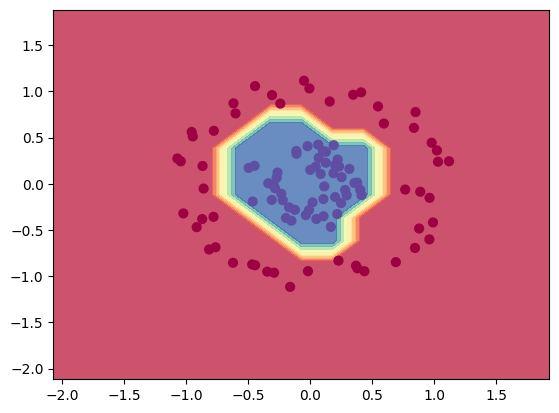

In [19]:
plot_decision_boundary(trained_model)